<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>


<p><font size="5" color='grey'> <b>
XAI Frameworks im Vergleich - Titanic
</b></font> </br></p>

---

**Explainable AI (XAI) Frameworks:**

- 🔍 **LIME** - Local Interpretable Model-agnostic Explanations
- 🎯 **SHAP** - SHapley Additive exPlanations  
- 👶 **ELI5** - Explain Like I'm 5
- 🏢 **InterpretML** - Microsoft's umfassendes Framework
- 📈 **ALE** - Accumulated Local Effects

Dieses Notebook vergleicht wichtige XAI-Frameworks am Titanic-Datensatz.



**📚 Wichtige Begriffe für dieses Notebook:**

| Begriff | Bedeutung |
|---------|----------|
| **Black-Box-Modell** | ML-Modell, dessen Entscheidungslogik nicht direkt einsehbar ist (z.B. Random Forest, neuronale Netze) |
| **Modell-agnostisch** | Die Methode funktioniert bei jedem Modelltyp – egal ob Random Forest, XGBoost oder neuronales Netz |
| **Lokal vs. Global** | Lokal = erklärt eine einzelne Vorhersage; Global = erklärt das gesamte Modellverhalten |
| **Feature Importance** | Wie wichtig ist ein Merkmal für die Vorhersage? |
| **Perturbation** | Gezieltes Verändern von Eingabewerten, um deren Einfluss zu messen |


In [1]:
#@markdown   <p><font size="4" color='green'>  XAI-Methoden</font> </br></p>

import base64
from IPython.display import Image, display

diagram = """
flowchart TB
    XAI[XAI-Methoden] --> GLOBAL[Global Gesamtmodell]
    XAI --> LOCAL[Lokal Einzelvorhersage]

    %% Globaler Zweig
    GLOBAL --> SHAP_G[SHAP Feature Importance]
    GLOBAL --> PERM[Permutation Importance]
    GLOBAL --> INTR[Modell-intrinsisch z.B. Decision Tree]
    GLOBAL --> AGNO[Modellagnostisch z.B. SHAP]

    %% Lokaler Zweig
    LOCAL --> LIME[LIME]
    LOCAL --> SHAP_L[SHAP Waterfall]

    %% Styling
    classDef globalFill fill:#e1f5fe,stroke:#01579b,stroke-width:2px;
    classDef localFill fill:#f1f8e9,stroke:#33691e,stroke-width:2px;
    classDef main fill:#fff4e5,stroke:#ff6f00,stroke-width:2px,font-weight:bold;

    class XAI main;
    class GLOBAL,SHAP_G,PERM,INTR,AGNO globalFill;
    class LOCAL,LIME,SHAP_L localFill;
"""

encoded = base64.urlsafe_b64encode(diagram.strip().encode()).decode()
display(Image(url=f"https://mermaid.ink/img/{encoded}", width=1100))

# 0  | Install & Import
---

In [2]:
# Install
!uv pip install -q shap lime eli5 interpret pyale
!uv pip install -q git+https://github.com/parrt/dtreeviz.git
!uv pip install -q SALib

In [3]:
# Daten & Strukturen
from pandas import read_excel, DataFrame  # Excel laden und Daten verwalten
import numpy as np  # Numerische Operationen

# Datenvorverarbeitung
from sklearn.preprocessing import OrdinalEncoder  # Kategoriale Variablen encodieren

# Datenaufteilung
from sklearn.model_selection import train_test_split  # Train/Test-Split

# Modell
from sklearn.ensemble import RandomForestClassifier  # Ensemble-Klassifikationsmodell

# Evaluation & Metriken
from sklearn.metrics import accuracy_score  # Klassifikationsmetriken

# XAI Frameworks
import shap  # SHAP-Erklärungen
from lime.lime_tabular import LimeTabularExplainer  # Tabellarische LIME-Erklärungen
import eli5  # Modellinterpretation
from eli5.sklearn import PermutationImportance  # Feature-Importance via Permutation
from interpret import show  # Interpretierbarkeits-Visualisierung
from interpret.blackbox import ShapKernel  # SHAP Kernel Explainer

# Statistisches Framework
from SALib.sample import saltelli
from SALib.analyze import sobol

# Visualisierung
import plotly.express as px  # Interaktive Plots
import plotly.graph_objects as go
import matplotlib.pyplot as plt  # Klassische Visualisierung
import dtreeviz  # Baumvisualisierung

In [4]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# Matplotlib-spezifische Warnungen unterdrücken
import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)

# 1  | Understand
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

In [5]:
df = read_excel(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02_daten/05_tabellen/titanic.xlsx",
    usecols=["pclass", "survived", "sex", "age", "sibsp", "parch"],
)

data = df.copy()
target = data.pop("survived")

data.head()

,age,sex,sibsp,parch,pclass
0,22.0,male,1,0,3
1,38.0,female,1,0,1
2,26.0,female,0,0,3
3,35.0,female,1,0,1
4,35.0,male,0,0,3


#  2 | Prepare
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Train-Test-Split durchführen</br>
✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>


<font color='black' size="5">
Datentyp ermitteln
</font>


In [6]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<font color='black' size="5">
Train-Test-Split
</font>


In [7]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.20, stratify=target, random_state=42)

<font color='black' size="5">
Kodierung
</font>

In [8]:
encoder = OrdinalEncoder()
encoder.fit(data_train[cat_col])
data_train[cat_col] = encoder.transform(data_train[cat_col])
data_test[cat_col] = encoder.transform(data_test[cat_col])

# 3 | Modeling
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
🏃 Modellauswahl & Training
</font></p>


In [9]:
model = RandomForestClassifier(
    n_estimators=200,        # Mehr Bäume für stabilere Vorhersagen
    max_depth=5,             # Weniger tief = weniger Overfitting
    min_samples_split=10,    # Mind. 10 Samples für Split
    min_samples_leaf=5,      # Mind. 5 Samples pro Blatt
    max_features='sqrt',     # Nur Wurzel der Features pro Split
    random_state=42
)

model.fit(data_train, target_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
🎯 Accuracy
</font></p>


In [10]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

acc_train = accuracy_score(target_train, target_train_pred) * 100
acc_test = accuracy_score(target_test, target_test_pred) * 100

print(f"Train Accuracy: {acc_train:5.2f}%")
print(f"Test Accuracy:  {acc_test:5.2f}%")

Train Accuracy: 81.63%
Test Accuracy:  77.86%


<p><font color='black' size="5">
📝 Testpersonen: Rose & Jack
</font></p>

In [11]:
# Rose DeWitt Bukater (Kate Winslet) - Original-Werte (keine Skalierung!)
rose = DataFrame(
    {"age": [22], "sex": [0], "sibsp": [0], "parch": [1], "pclass": [1]},  # sex=0 (female)
    index=["Rose"],
)

# Jack Dawson (Leonardo DiCaprio) - Original-Werte (keine Skalierung!)
jack = DataFrame(
    {"age": [23], "sex": [1], "sibsp": [0], "parch": [0], "pclass": [3]},  # sex=1 (male)
    index=["Jack"],
)

# Spaltenreihenfolge an Trainingsdaten angleichen
rose = rose[data_train.columns]
jack = jack[data_train.columns]

rose_pred = model.predict_proba(rose)[0][1] * 100
jack_pred = model.predict_proba(jack)[0][1] * 100

print(f"Rose Ueberlebenschance: {rose_pred:.2f}%")
print(f"   (22 Jahre, weiblich, 1. Klasse)")
print(f"Jack Ueberlebenschance: {jack_pred:.2f}%")
print(f"   (23 Jahre, maennlich, 3. Klasse)")

Rose Ueberlebenschance: 62.43%
   (22 Jahre, weiblich, 1. Klasse)
Jack Ueberlebenschance: 7.23%
   (23 Jahre, maennlich, 3. Klasse)


<p><font color='black' size="5">
🌳 Entscheidungsbaum Visualisierung
</font></p>

**Hinweis**: RandomForest besteht aus 200 Bäumen. Hier wird nur der ersten Baum als Beispiel visualisiert.


In [12]:
# Extrahiere den ersten Baum aus dem RandomForest
single_tree = model.estimators_[1]

# Erstelle dtreeviz Visualisierung für diesen einzelnen Baum
viz_model = dtreeviz.model(
    single_tree,
    X_train=data_train,
    y_train=target_train,
    target_name="survived",
    class_names=["not survived", "survived"],
    feature_names=list(data_train.columns),
)

print(f"✅ Visualisierung für Baum 1 von {model.n_estimators} erstellt")

✅ Visualisierung für Baum 1 von 200 erstellt


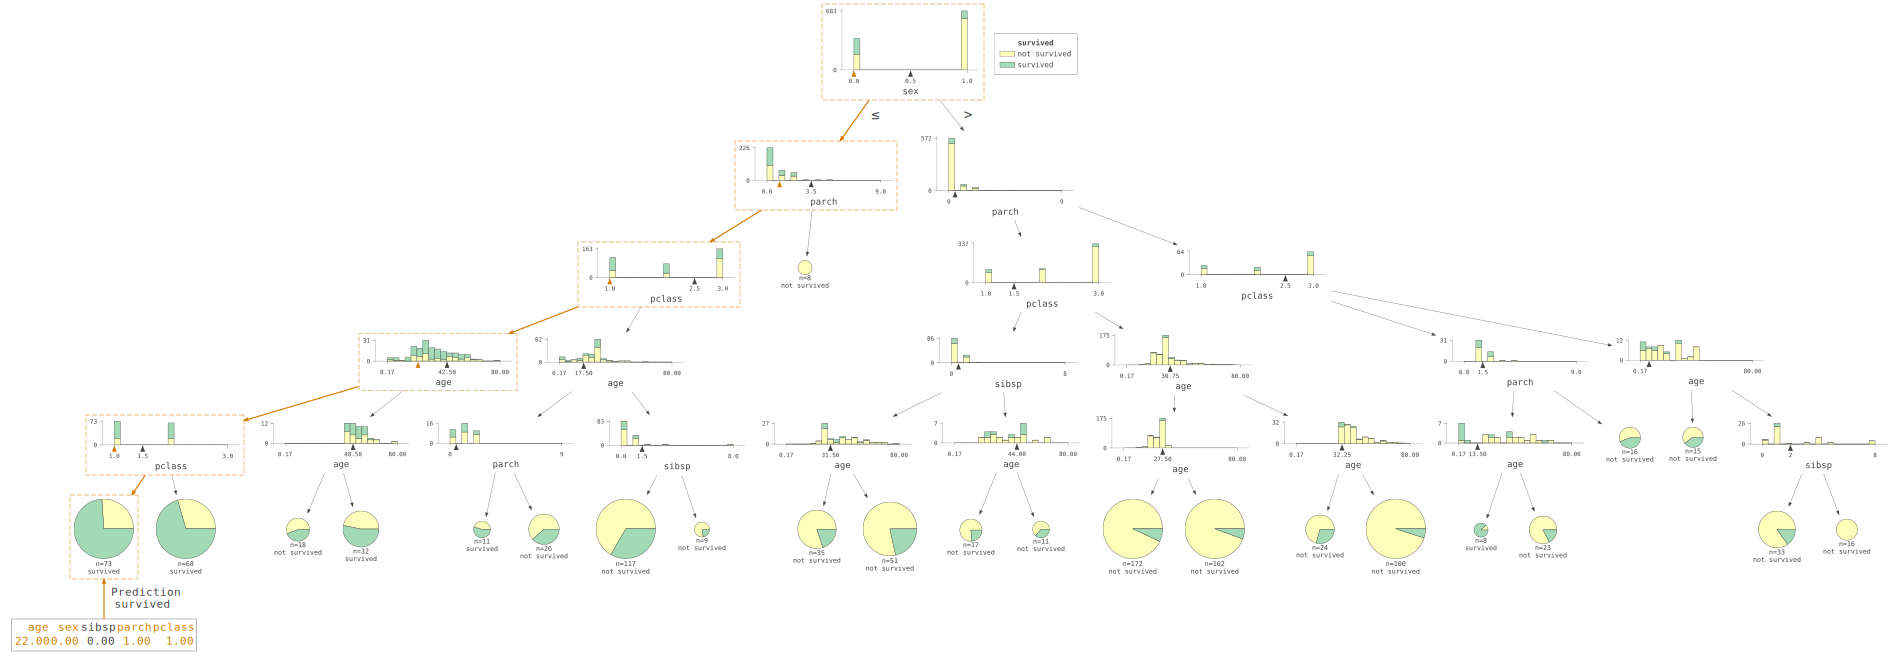

In [13]:
# Local Explanation für Rose - total
one = rose.iloc[0].values
viz_model.view(x=one, scale=1.0, fontname="Monospace")

Der vollständige Baum zeigt alle Entscheidungspfade: Farbige Knoten = Mehrheit der Klasse,
Breite der Knoten = Anzahl Samples, Pfad für Rose (22, weiblich, 1. Klasse) ist hervorgehoben.

> Hinweis: Dies ist nur **Baum 1** von 200 — jeder Baum im RandomForest trifft leicht
> unterschiedliche Entscheidungen. Die finale Vorhersage ist der Durchschnitt aller 200 Bäume.


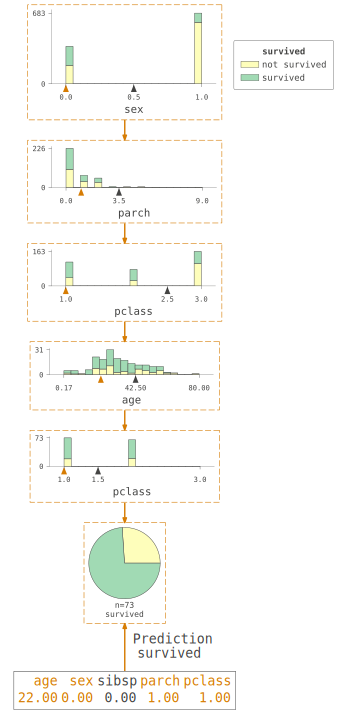

In [14]:
# local Explanation - single
viz_model.view(x=one, scale=1.2, show_just_path=True, fontname="Monospace")

Der Entscheidungspfad zeigt nur die Knoten, die für Roses Vorhersage relevant sind:
Das Modell prüft zuerst das Geschlecht, dann die Klasse — und kommt damit direkt
zur hohen Überlebenswahrscheinlichkeit. Die restlichen Features spielen auf diesem Pfad keine Rolle.


# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# 🌐 Global Frameworks
---

In [15]:
#@markdown   <p><font size="4" color='green'>  XAI-Methoden</font> </br></p>

import base64
from IPython.display import Image, display

diagram = """
graph TD
    %% Header
    Start((Start)) --> GlobalSection

    subgraph GlobalSection [<b>Gesamtmodell&nbsp;verstehen</b>]
        A[A: Feature Importance] --> B[B: ELI5 Permutation]
        B --> C[C: SHAP Global]
        C --> D[D: ALE Plots]
        D --> E[E: Sobol Indizes]
    end

    GlobalSection --> LocalSection

    subgraph LocalSection [<b>Einzelvorhersagen&nbsp;verstehen</b>]
        F[F: LIME] --> G[G: ELI5 Vorhersage]
        G --> H[H: SHAP Lokal Waterfall]
        H --> I[I: InterpretML Dashboard]
        I --> J[J: Ceteris Paribus]
        J --> K[K: Counterfactuals]
    end

    %% Highlight Einsteiger-Pfad
    linkStyle 0,1,5,6,9,10 stroke:#ff6f00,stroke-width:4px;

    %% Styling
    classDef globalStyle fill:#e1f5fe,stroke:#01579b,color:#01579b
    classDef localStyle fill:#f1f8e9,stroke:#33691e,color:#33691e
    classDef highlight fill:#fff3e0,stroke:#ff6f00,stroke-width:2px,font-weight:bold

    class A,B,C,D,E globalStyle
    class F,G,H,I,J,K localStyle
"""

encoded = base64.urlsafe_b64encode(diagram.strip().encode()).decode()
display(Image(url=f"https://mermaid.ink/img/{encoded}", width=1100))

**Reihenfolge der XAI-Methoden**

Dieses Notebook folgt einer didaktisch aufgebauten Reihenfolge:
**erst Global, dann Lokal** — vom Überblick zum Detail, von einfach zu komplex.

**Global — Was ist dem Modell insgesamt wichtig?**

| | Methode | Konzept | Komplexität |
|-|---------|---------|-------------|
| **A** | Feature Importance | Direkt aus dem Modell — keine Abstraktion | ⭐ |
| **B** | ELI5 Permutation Importance | Wie stark bricht das Modell ohne ein Feature ein? | ⭐⭐ |
| **C** | SHAP Global | Fairer Beitrag jedes Features (Spieltheorie) | ⭐⭐⭐ |
| **D** | ALE | Trendanalyse bei korrelierten Features | ⭐⭐⭐ |
| **E** | Sobol *(Vertiefung)* | Interaktionen zwischen Features messen | ⭐⭐⭐⭐⭐ |




**Lokal — Warum hat das Modelzl diese Vorhersage getroffen?**
| | Methode | Konzept | Komplexität |
|-|---------|---------|-------------|
| **F** | LIME | Lokales Modell um einen Datenpunkt — intuitiv | ⭐⭐ |
| **G** | ELI5 Vorhersage | Einfachste lokale Erklärung | ⭐⭐ |
| **H** | SHAP Lokal (Waterfall) | Fundierte Einzelfall-Erklärung | ⭐⭐⭐ |
| **I** | InterpretML | Dashboard für professionelle Analyse | ⭐⭐⭐ |
| **J** | Ceteris Paribus | Was-wäre-wenn — ein Feature variieren | ⭐⭐ |
| **K** | Counterfactual | Minimale Änderung für eine andere Entscheidung | ⭐⭐ |


# A | Feature Importance 🌲
---

**Lokal vs. Global – Was ist der Unterschied?**

Bisher wurden i.W. **einzelne Vorhersagen** erklärt (lokal). Jetzt folgen Erklärungen zum **gesamte Modellverhalten** (global).

| Scope | Frage | Beispiel |
|-------|-------|----------|
| **Lokal** | Warum wurde *diese* Vorhersage gemacht? | Warum überlebt Rose mit 92%? |
| **Global** | Wie verhält sich das Modell *insgesamt*? | Welches Feature ist generell am wichtigsten? |



**Globale Methoden in diesem Notebook**

- **ELI5**: Rangfolge der Einflussfaktoren
- **Feature Importance**: Eingebaute Wichtigkeit basierend auf Entscheidungsbäumen
- **SHAP (global aggregiert)**: Aggregierte Einzelwerte


<p><font color='black' size="5">
🌲 Feature Importance (Baum)
</font></p>

**Konzept**: Zeigt, wie oft und wie stark jedes Feature zur Entscheidungsfindung beiträgt.


In [16]:
# Feature Importance aus RandomForest extrahieren
feature_importance = DataFrame({
    'Feature': data_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualisierung
fig = px.bar(
    feature_importance,
    x='Importance',
    y='Feature',
    orientation='h',
    title='RandomForest Feature Importance (Global)',
    labels={'Importance': 'Wichtigkeit', 'Feature': 'Feature'},
    color='Importance',
    color_continuous_scale='viridis',
    category_orders={'Feature': feature_importance['Feature'].tolist()} # Sortiere absteigend
)

fig.update_layout(height=400)
fig.show()

print("\n📊 Feature Importance Ranking:")
for idx, row in feature_importance.iterrows():
    print(f"  {row['Feature']:10s}: {row['Importance']:.4f}")


📊 Feature Importance Ranking:
  sex       : 0.4847
  age       : 0.2136
  pclass    : 0.2026
  parch     : 0.0552
  sibsp     : 0.0438


Feature Importance ist die **direkteste** Methode, die Wichtigkeit von Merkmalen zu messen:
Sie stammt unmittelbar aus dem Modell und zeigt, wie oft und wie stark jedes Feature
zur Entscheidungsfindung beiträgt.

**Vorteil:** Kein zusätzlicher Rechenaufwand — das Modell liefert die Werte gratis.

**Grenze:** Zeigt nur *wie wichtig*, nicht *in welche Richtung* ein Feature wirkt.
Bei korrelierten Features kann die Wichtigkeit auch verzerrt sein.


# B | ELI5 Permutation Importance 👶
---

**ELI5** = Explain Like I'm 5 (Erkläre es mir wie einem 5-Jährigen)

**Was macht ELI5?**

ELI5 ist das **einfachste** XAI-Framework. Es fokussiert sich auf **Permutation Importance** – eine intuitive Methode zur Messung der Feature-Wichtigkeit.

**Was ist Permutation Importance?**

Die Grundidee ist simpel: **Wenn ein Feature wichtig ist, wird das Modell schlechter, wenn wir es "kaputt machen".**

**So funktioniert es:**
1. Miss die Modell-Accuracy auf den Testdaten
2. Mische die Werte eines Features zufällig durch ("permutieren")
3. Miss erneut die Accuracy
4. **Differenz** = Wichtigkeit des Features

**Beispiel:**
- Original-Accuracy: 85%
- Accuracy nach Durchmischen von "Geschlecht": 65%
- → Importance(Geschlecht) = 85% - 65% = **20%** (sehr wichtig!)

**Warum "Like I'm 5"?**

- Minimaler Code (oft nur 3 Zeilen)
- Keine komplexe Mathematik
- Ergebnis ist sofort verständlich: "Feature X ist am wichtigsten"

**Einschränkungen**
- ⚠️ Zeigt nur **wie wichtig**, nicht **warum** oder **in welche Richtung**
- ⚠️ Primär für **globale** Erklärungen (nicht für einzelne Vorhersagen)


<p><font color='black' size="5">
⚙️ Permutation Importance
</font></p>

In [17]:
# Permutation Importance berechnen
perm = PermutationImportance(model, random_state=42).fit(data_test, target_test)

In [18]:
# Permutation Importance als Plotly-Balkendiagramm (absteigend)
df_weights = eli5.explain_weights_df(perm, feature_names=data.columns.tolist())
df_weights = df_weights.sort_values("weight")

fig = px.bar(
    df_weights, x="weight", y="feature", orientation="h",
    error_x="std",
    title="ELI5: Permutation Importance – global (absteigend)",
    labels={"weight": "Wichtigkeit", "feature": "Feature"},
)
fig.update_layout(height=350)
fig.show()

**📊 Rangfolge der Einflussfaktoren - GLOBAL**
+ sex (0.0855 ± 0.0276)    
    → klar wichtigster Faktor     
    → Modell unterscheidet stark nach Geschlecht
+ pclass (0.0557 ± 0.0322)     
    → zweitwichtigster Einfluss     
    → Ticketklasse spielt große Rolle
+ sibsp (0.0176 ± 0.0037)   
    → moderater Einfluss   
    → Begleitung (Geschwister/Ehepartner) hat gewisse Bedeutung   
+ age (0.0137 ± 0.0124)     
    → eher schwach und unsicher    
    → Alter wird genutzt, aber inkonsistent
+ parch (0.0031 ± 0.0057)    
    → praktisch irrelevant - Einfluss nahe Null  


**🧠 Kernaussage**   

> Das Modell basiert hauptsächlich auf zwei Faktoren: Geschlecht und Klasse
→ alle anderen Features sind deutlich weniger wichtig

# C | SHAP Global 🎯
---

<p><font color='black' size="5">
SHAP Global
</font></p>

In [19]:
# SHAP TreeExplainer initialisieren (wird in B + F verwendet)
shap_explainer = shap.TreeExplainer(model)
print("SHAP TreeExplainer bereit")

SHAP TreeExplainer bereit


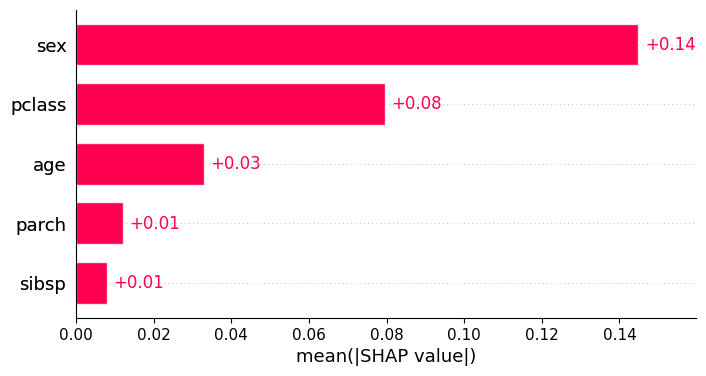

In [20]:
# SHAP-Werte für die gesamten Trainingsdaten berechnen
shap_values_global = shap_explainer(data_train)

# SHAP Summary Bar Plot (Mean |SHAP|) für Klasse 1 (Survived)
# Berechnet den durchschnittlichen absoluten SHAP-Wert pro Feature
shap.plots.bar(shap_values_global[:, :, 1])

💡 SHAP (global aggregiert) - SHAP Summary Plot**

*Global aggregiert* bedeutet hier, dass nicht nur eine einzelne Vorhersage (wie z.B. nur für Rose oder nur für Jack) betrachtet werden, sondern das Verhalten des Modells über alle Datenpunkte (Passagiere) hinweg zusammenfassen (aggregiert).

**Vorteil:**
   - konsistent, theoretisch fundiert
   - zeigt Richtung + Stärke (in der Bienen-Schwarm-Ansicht, das Balkendiagramm zeigt die absolute Stärke)

👉 besser als klassische Feature Importance

# D | ALE – Accumulated Local Effects 📈
---

**ALE** = Accumulated Local Effects

**Was macht ALE?**

ALE misst den **durchschnittlichen Einfluss** eines Features auf die Vorhersage.
**Kernidee:**

ALE schaut auf **lokale Nachbarschaften**: kleine Intervalle, in denen die übrigen Features annähernd konstant gehalten werden.

| Methode | Vorgehen | Problem |
|---------|----------|---------|
| **PDP** | Feature auf festen Wert setzen, über **alle** Daten mitteln | Unrealistische Kombinationen bei korrelierten Features |
| **ICE** | Wie PDP, aber eine Kurve **pro Instanz** | Gleiche Korrelationsproblematik; bei vielen Instanzen unübersichtlich |
| **ALE** | Lokale Intervalle betrachten, Effekte akkumulieren | ✅ Kein Korrelationsproblem; zentriert auf 0 |

<br>

**Interpretation:**
- ALE-Wert **> 0**: Feature-Wert erhöht die Vorhersage *relativ zum Durchschnitt*
- ALE-Wert **< 0**: Feature-Wert senkt die Vorhersage relativ zum Durchschnitt
- Der Durchschnitt aller ALE-Werte ist immer 0 (zentriert)

**Grenze:** ALE erklärt globale Trends – nicht einzelne Vorhersagen.

**In der Praxis relevant wenn:** Features korreliert sind (z.B. `pclass` und `age`) und PDP verzerrte Ergebnisse liefert.


In [21]:
from PyALE import ale

POS = "#636EFA"  # positiver Effekt
NEG = "#EF553B"  # negativer Effekt

print("PyALE geladen – berechne ALE-Effekte pro Feature")

PyALE geladen – berechne ALE-Effekte pro Feature


In [22]:
# ALE: age (kontinuierlich) - Liniendiagramm
result_age = ale(
    X=data_train, model=model,
    feature=["age"], feature_type="continuous",
    grid_size=20, include_CI=True, C=0.95, plot=False
)
fig = px.line(
    x=result_age.index.tolist(), y=result_age["eff"].tolist(),
    title="ALE: age - Einfluss auf Ueberlebenschance",
    labels={"x": "Alter", "y": "ALE-Effekt (Abweichung vom Durchschnitt)"},
)
fig.add_hline(y=0, line_dash="dash", line_color="gray",
              annotation_text="Kein Effekt")
fig.update_layout(height=350)
fig.show()

Das Diagramm zeigt, wie das Alter **relativ zum Durchschnitt** die Überlebenschance beeinflusst.

- Sehr junge Passagiere (< 10 Jahre): deutlich positiver Effekt — "Women and children first"
- Alter 15–35: nahe 0, kaum Einfluss
- Höheres Alter (> 50): leicht negativ, aber schwacher Effekt

In der Praxis relevant wenn: Das Modell stark auf Alter reagiert. Hier ist der Alterseffekt
schwächer als Geschlecht und Klasse — bestätigt die Erkenntnisse aus SHAP und ELI5.


In [23]:
# ALE: sex (diskret, stärkster Effekt) → Balkendiagramm
result_sex = ale(
    X=data_train, model=model,
    feature=["sex"], feature_type="discrete", include_CI=True, plot=False
)
df_sex = DataFrame({
    "Wert":   [str(v) for v in result_sex.index.tolist()],
    "Effekt": result_sex["eff"].tolist()
}).sort_values("Effekt")
df_sex["Richtung"] = ["positiv" if v >= 0 else "negativ" for v in df_sex["Effekt"]]

fig = px.bar(
    df_sex, x="Effekt", y="Wert", orientation="h",
    color="Richtung",
    color_discrete_map={"positiv": POS, "negativ": NEG},
    title="ALE: sex – Einfluss auf Überlebenschance",
    labels={"Effekt": "ALE-Effekt", "Wert": "sex (0=female, 1=male)"},
)
fig.update_layout(showlegend=False, height=250)
fig.show()

Geschlecht ist der dominante Faktor im Modell:

- `sex=0` (weiblich): **stark positiver** ALE-Effekt — Frauen hatten deutlich höhere Überlebenschancen
- `sex=1` (männlich): **stark negativer** Effekt — Männer hatten deutlich geringere Chancen

Grenze: ALE zeigt den *isolierten* Effekt von Geschlecht. Die tatsächliche Überlebenschance
hängt immer noch von allen Features zusammen ab.


In [24]:
# ALE: pclass (diskret, zweiter Haupttreiber) → Balkendiagramm
result_pclass = ale(
    X=data_train, model=model,
    feature=["pclass"], feature_type="discrete", include_CI=True, plot=False
)
df_pclass = DataFrame({
    "Wert":   [str(v) for v in result_pclass.index.tolist()],
    "Effekt": result_pclass["eff"].tolist()
}).sort_values("Effekt")
df_pclass["Richtung"] = ["positiv" if v >= 0 else "negativ" for v in df_pclass["Effekt"]]

fig = px.bar(
    df_pclass, x="Effekt", y="Wert", orientation="h",
    color="Richtung",
    color_discrete_map={"positiv": POS, "negativ": NEG},
    title="ALE: pclass – Einfluss auf Überlebenschance",
    labels={"Effekt": "ALE-Effekt", "Wert": "Passagierklasse"},
)
fig.update_layout(showlegend=False, height=280)
fig.show()

Die Passagierklasse zeigt einen klaren Gradienten:

- 1. Klasse: **positiver** Effekt — Nähe zu den Rettungsbooten, bessere Informationslage
- 2. Klasse: nahe 0 — mittlerer Effekt
- 3. Klasse: **negativer** Effekt — schlechterer Zugang, weiter von den Booten entfernt

Typischer Fehler: pclass und age sind im Titanic-Datensatz leicht korreliert
(höhere Klassen tendieren zu älteren Passagieren). ALE ist hier zuverlässiger als PDP.


In [25]:
# ALE: sibsp + parch (familiäre Begleitung) → kleine Effekte
for feat in ["sibsp", "parch"]:
    result = ale(
        X=data_train, model=model,
        feature=[feat], feature_type="discrete", include_CI=True, plot=False
    )
    df_f = DataFrame({
        "Wert":   [str(v) for v in result.index.tolist()],
        "Effekt": result["eff"].tolist()
    }).sort_values("Effekt")
    df_f["Richtung"] = ["positiv" if v >= 0 else "negativ" for v in df_f["Effekt"]]

    fig = px.bar(
        df_f, x="Effekt", y="Wert", orientation="h",
        color="Richtung",
        color_discrete_map={"positiv": POS, "negativ": NEG},
        title="ALE: " + feat + " – Einfluss auf Überlebenschance",
        labels={"Effekt": "ALE-Effekt", "Wert": feat},
    )
    fig.update_layout(showlegend=False, height=280)
    fig.show()

Familiäre Begleitung hat einen deutlich schwächeren Effekt als Geschlecht und Klasse:

- **sibsp** (Geschwister/Ehepartner): 1–2 Begleitpersonen leicht positiv, viele negativ
- **parch** (Eltern/Kinder): ähnliches Muster — kleine Gruppe positiv, allein reisen nahe 0

Interpretation: Mit einer kleinen Familiengruppe war es leichter, gemeinsam ein Rettungsboot
zu finden. Sehr große Gruppen hatten es schwerer.

> Diese Effekte sind klein — sie erklären kaum Varianz (vgl. Sobol-Abschnitt).


**🧠 Kernaussagen**

- **`sex`**: Weiblich (0) → stark positiver ALE-Effekt, männlich (1) → stark negativ → Geschlecht dominiert
- **`pclass`**: 1. Klasse → positiv, 3. Klasse → negativ → Klasse ist zweithäufigster Treiber
- **`age`**: Junge Passagiere haben leicht höhere Überlebenschance; Effekt flacht ab ~40 Jahren
- **`sibsp`/`parch`**: Geringe Effekte; allein reisen ist marginal schlechter als mit 1–2 Familienmitgliedern

> ALE bestätigt die Erkenntnisse aus SHAP und ELI5, ist aber robuster bei korrelierten Features.


# E | Global Sensitivity Analysis (Sobol) – Vertiefung 🌐
---


**Was ist das?**
Eine Methode, die ursprünglich stark aus der Statistik und Systemsimulation stammt, aber extrem mächtig für die Analyse von Machine Learning Modellen ist.

👉 **Misst:** Wie stark beeinflussen die verschiedenen Inputs (Features) die Varianz des Outputs (Vorhersage)?

**Kernidee:**
Die gesamte Varianz der Modellvorhersagen wird in Bruchteile zerlegt, die einzelnen Features oder Interaktionen zwischen Features zugeordnet werden können.

- **First-order Sobol index:** Welchen Anteil an der Varianz erklärt das Feature isoliert?
- **Total-order Sobol index:** Welchen Anteil erklärt das Feature inklusive all seiner Interaktionen mit anderen Features?

*Diese Methode ist mathematisch sehr robust, erfordert aber oft viele Modellaufrufe (Samples) und kann rechenintensiv sein.*

In [26]:
# Problem definieren (Grenzen für unsere Titanic-Features)
problem = {
    'num_vars': len(data_train.columns),
    'names': data_train.columns.tolist(),
    'bounds': [
        [data_train['age'].min(), data_train['age'].max()],
        [0, 1],                           # sex (0=female, 1=male)
        [0, data_train['sibsp'].max()],   # sibsp
        [0, data_train['parch'].max()],   # parch
        [1, 3]                            # pclass (1., 2., 3. Klasse)
    ]
}

# Samples generieren (N=1024 ist eine gängige Basis-Größe für SALib)
# Erzeugt N * (2D + 2) Samples
X_samples_array = saltelli.sample(problem, 1024)
X_samples = DataFrame(X_samples_array, columns=problem['names'])

# SALib zieht kontinuierliche Werte. Wir runden die diskreten Features.
X_samples['sex'] = X_samples['sex'].round()
X_samples['sibsp'] = X_samples['sibsp'].round()
X_samples['parch'] = X_samples['parch'].round()
X_samples['pclass'] = X_samples['pclass'].round()

# Vorhersagen (Wahrscheinlichkeit für 'Survived') berechnen
y_pred = model.predict_proba(X_samples)[:, 1]

# Sobol Indices berechnen
Si = sobol.analyze(problem, y_pred)

# Ergebnisse aufbereiten und visualisieren
sobol_df = DataFrame({
    'Feature': problem['names'],
    'First-order (S1)': Si['S1'],
    'Total-order (ST)': Si['ST']
})

fig = go.Figure(data=[
    go.Bar(name='First-order (S1 - isolierter Einfluss)',
           x=sobol_df['Feature'], y=sobol_df['First-order (S1)'], marker_color='royalblue'),
    go.Bar(name='Total-order (ST - inkl. Interaktionen)',
           x=sobol_df['Feature'], y=sobol_df['Total-order (ST)'], marker_color='darkorange')
])

fig.update_layout(
    title='Global Sensitivity Analysis: Sobol Indices (Titanic)',
    barmode='group',
    yaxis_title='Sobol Index (Anteil an der Varianz)',
    xaxis_title='Feature'
)
fig.show()

💡 **Interpretation des Diagramms:**

- **Blau (First-order / S1):** Zeigt den isolierten Einfluss eines Features, also wie viel der Varianz in den Vorhersagen allein durch dieses eine Feature erklärt wird.
- **Orange (Total-order / ST):** Beschreibt den gesamten Einfluss des Features, inklusive aller Wechselwirkungen (Interaktionen) mit anderen Features.

Es wird deutlich, dass **sex (Geschlecht)** und **pclass (Passagierklasse)** die mit Abstand wichtigsten Faktoren sind – sowohl isoliert betrachtet als auch in Kombination mit anderen Variablen.

# 🏠 Lokale Frameworks

# F | XAI mit LIME 🔍
---

**LIME** = Local Interpretable Model-agnostic Explanations

**Was macht LIME?**

LIME erklärt **einzelne Vorhersagen**, indem es ein einfaches, verständliches Modell lokal um den zu erklärenden Datenpunkt herum trainiert.

**Wie funktioniert LIME?**

1. **Perturbation**: LIME erzeugt viele leicht veränderte Versionen des Datenpunkts (z.B. Alter ±5 Jahre, andere Klasse)
2. **Vorhersagen sammeln**: Das Black-Box-Modell bewertet alle *perturbierten* Samples
3. **Gewichtung**: Samples, die dem Original ähnlicher sind, bekommen mehr Gewicht
4. **Lokales Modell**: Ein einfaches Modell wird auf diese gewichteten Samples trainiert
5. **Interpretation**: Die Koeffizienten des Modells zeigen den Einfluss jedes Features

**Warum "lokal"**?

LIME erklärt nicht das gesamte Modell, sondern nur die **unmittelbare Umgebung** eines Datenpunkts. Die Erklärung für Rose kann völlig anders aussehen als die für Jack.

**Vorteile**
- ✅ Funktioniert mit **jedem** Modell (modell-agnostisch)
- ✅ Sehr **intuitiv** zu verstehen
- ✅ **Schnell** für einzelne Vorhersagen


In [27]:
# LIME Explainer mit vorverarbeiteten Daten erstellen
lime_explainer = LimeTabularExplainer(
    data_train.values,
    feature_names=data_train.columns.tolist(),
    class_names=['Not Survived', 'Survived'],
    categorical_features=[data_train.columns.get_loc('sex'), data_train.columns.get_loc('pclass')],
    mode='classification'
)

print("✅ LIME Explainer erstellt")
print("   Features:", data_train.columns.tolist())

✅ LIME Explainer erstellt
   Features: ['age', 'sex', 'sibsp', 'parch', 'pclass']


💡 LIME Interpretation

<details>

**Balkendiagramm:**
- **Orange Balken**: Erhöhen die Überlebenschance (Klasse "Survived")
- **Blaue Balken**: Verringern die Überlebenschance (Klasse "Not Survived")
- **Werte**: Wie stark beeinflusst das Feature die Vorhersage

**PrScore (Prediction Score) Tabelle:**
- Zeigt die Vorhersage-Wahrscheinlichkeit für **beide Klassen**
- **Not Survived**: Wahrscheinlichkeit für Tod (höher bei Jack)
- **Survived**: Wahrscheinlichkeit für Überleben (höher bei Rose)
- Beide Werte zusammen ergeben immer 100%

**Beispiel:**
- Rose: Not Survived ≈ 38%, **Survived ≈ 62%**
- Jack: **Not Survived ≈ 93%**, Survived ≈ 7%

⚠️ **Wichtig**: Der PrScore für "Not Survived" ist bei Jack höher - das bedeutet er hat eine höhere Todeswahrscheinlichkeit, nicht eine höhere Überlebenschance!

**Erkenntnisse:**
- Rose: `sex=0` (female) und `pclass=1` erhöhen massiv die Überlebenschance
- Jack: `sex=1` (male) und `pclass=3` verringern massiv die Überlebenschance

</details>


<p><font color='black' size="5">
👰 Rose mit LIME erklären
</font></p>


In [28]:
# Rose mit LIME erklären
rose_lime_exp = lime_explainer.explain_instance(
    rose.iloc[0].values,
    model.predict_proba,
    num_features=5
)
df_lime_rose = DataFrame(rose_lime_exp.as_list(label=1), columns=["Feature", "Gewicht"])
df_lime_rose = df_lime_rose.sort_values("Gewicht")
df_lime_rose["Richtung"] = ["positiv" if v >= 0 else "negativ" for v in df_lime_rose["Gewicht"]]

fig = px.bar(
    df_lime_rose, x="Gewicht", y="Feature", orientation="h",
    color="Richtung",
    color_discrete_map={"positiv": "#636EFA", "negativ": "#EF553B"},
    title="LIME: Rose – Feature-Beiträge (Klasse: Survived)",
    labels={"Gewicht": "Gewichtung", "Feature": "Feature"},
)
fig.update_layout(showlegend=False, height=350)
fig.show()

Das Modell denkt im Prinzip:

> Jung + weiblich + 1. Klasse → sehr gute Überlebenschance

Die negativen Faktoren sind so klein, dass sie die Entscheidung kaum beeinflussen.

<p><font color='black' size="5">
🎨 Jack mit LIME erklären
</font></p>

In [29]:
# Jack mit LIME erklären
jack_lime_exp = lime_explainer.explain_instance(
    jack.iloc[0].values,
    model.predict_proba,
    num_features=5
)
df_lime_jack = DataFrame(jack_lime_exp.as_list(label=1), columns=["Feature", "Gewicht"])
df_lime_jack = df_lime_jack.sort_values("Gewicht")
df_lime_jack["Richtung"] = ["positiv" if v >= 0 else "negativ" for v in df_lime_jack["Gewicht"]]

fig = px.bar(
    df_lime_jack, x="Gewicht", y="Feature", orientation="h",
    color="Richtung",
    color_discrete_map={"positiv": "#636EFA", "negativ": "#EF553B"},
    title="LIME: Jack – Feature-Beiträge (Klasse: Survived)",
    labels={"Gewicht": "Gewichtung", "Feature": "Feature"},
)
fig.update_layout(showlegend=False, height=350)
fig.show()

Das Modell folgt hier ziemlich klar dem klassischen Titanic-Muster:

> Männlich + 3. Klasse → sehr geringe Überlebenschance

Die Entscheidung wird fast vollständig durch Geschlecht und Klasse getragen.

# G | ELI5 Vorhersage – Lokal 👶
---

<p><font color='blue' size="4">
💡 ELI5 Interpretation
</font></p>

**LOKAL:**

**Permutation Importance:**
- Misst, wie stark die Modell-Accuracy sinkt, wenn ein Feature zufällig permutiert wird
- ± Werte = Unsicherheit der Messung

**Vorhersage-Erklärung:**
- Zeigt Feature-Werte und ihre Beiträge zur Vorhersage
- Sehr einfach zu verstehen!

Der **Basiswert** ist mal positiv, mal negativ, weil er auf einer internen Skala (Log-Odds) liegt – nicht auf der Wahrscheinlichkeitsskala.

+ → Negativ heißt: Modell startet unter 50 %
+ → Positiv heißt: Modell startet über 50 %

---


**🧠 Log-Odds (ELI15)**

Mann kennt Wahrscheinlichkeiten:

+ 0 % → unmöglich
+ 50 % → unentschieden
+ 100 % → sicher

Das Problem:    
👉 Mit Wahrscheinlichkeiten kann man nicht gut addieren

🔄 Lösung: Log-Odds

Man wandelt Wahrscheinlichkeiten in eine Skala um, auf der man linear rechnen kann:

+ 0 → entspricht 50 %
+ positive Werte → eher wahrscheinlich
+ negative Werte → eher unwahrscheinlich

Diese Skala nennt man Log-Odds

<p><font color='black' size="5">
👰 Rose mit ELI5 erklären
</font></p>


In [30]:
# Einzelne Vorhersage erklären – Rose
df_rose = eli5.format_as_dataframe(
    eli5.explain_prediction(model, rose.iloc[0], feature_names=rose.columns.tolist())
)
df_rose = df_rose.sort_values("weight")
df_rose["Richtung"] = ["positiv" if v >= 0 else "negativ" for v in df_rose["weight"]]

fig = px.bar(
    df_rose, x="weight", y="feature", orientation="h",
    color="Richtung",
    color_discrete_map={"positiv": "#636EFA", "negativ": "#EF553B"},
    title="ELI5: Rose – Feature-Beiträge",
    labels={"weight": "Gewichtung", "feature": "Feature"},
)
fig.update_layout(showlegend=False, height=350)
fig.show()

Das Modell startet bei einem Basiswert von etwa 26 % Überlebenswahrscheinlichkeit. Von dort aus wird die Vorhersage schrittweise angepasst:
+ Den größten positiven Einfluss hat das **Geschlecht** (wahrscheinlich weiblich), gefolgt von der ersten **Klasse**.
+ Beide Faktoren erhöhen die Überlebenschance deutlich. Kleinere positive Beiträge kommen durch familiäre Begleitung.
+ Das Alter wirkt leicht negativ, spielt aber kaum eine Rolle.

<p><font color='black' size="5">
🎨 Jack mit ELI5 erklären
</font></p>


In [31]:
# Einzelne Vorhersage erklären – Jack
df_jack = eli5.format_as_dataframe(
    eli5.explain_prediction(model, jack.iloc[0], feature_names=jack.columns.tolist(), targets=[1])
)
df_jack = df_jack.sort_values("weight")
df_jack["Richtung"] = ["positiv" if v >= 0 else "negativ" for v in df_jack["weight"]]

fig = px.bar(
    df_jack, x="weight", y="feature", orientation="h",
    color="Richtung",
    color_discrete_map={"positiv": "#636EFA", "negativ": "#EF553B"},
    title="ELI5: Jack – Feature-Beiträge (Klasse: Survived)",
    labels={"weight": "Gewichtung", "feature": "Feature"},
)
fig.update_layout(showlegend=False, height=350)
fig.show()

Das Modell startet hier mit einem stark negativen Basiswert, der bereits eine sehr geringe Überlebenswahrscheinlichkeit impliziert.

Die einzelnen Merkmale dieser Person wirken zwar alle in Richtung einer höheren Überlebenschance – insbesondere Geschlecht und Klasse tragen etwas positiv bei –, aber diese Effekte sind zu schwach, um den niedrigen Ausgangswert wesentlich zu verändern.

Auch Alter und familiäre Situation liefern nur kleine Korrekturen und spielen praktisch keine entscheidende Rolle.

# H | XAI mit SHAP – Lokal 🎯
---

**SHAP** = SHapley Additive exPlanations

**Was macht SHAP?**

SHAP berechnet den **Beitrag jedes Features** zur Vorhersage, basierend auf einem mathematisch fundierten Konzept aus der Spieltheorie.

**Die Spieltheorie-Idee (vereinfacht**)

Als Analogie lässt sich ein Team von Spielern vorstellen, das gemeinsam einen Preis gewinnt. Wie verteilt man den Gewinn **fair**? Die Shapley-Werte lösen genau dieses Problem.

**Übertragen auf ML:**
- **Spieler** = Features (Alter, Geschlecht, Klasse, ...)
- **Gewinn** = Vorhersage des Modells
- **Frage**: Wie viel trägt jedes Feature zur Vorhersage bei?

**Wie funktioniert SHAP**?

1. Betrachte **alle möglichen Kombinationen** von Features
2. Berechne für jede Kombination: Was ändert sich, wenn ich Feature X hinzufüge?
3. Der **Durchschnitt** über alle Kombinationen = SHAP-Wert des Features

**Interpretation der SHAP-Werte**

| SHAP-Wert | Bedeutung |
|-----------|----------|
| **Positiv (+)** | Feature erhöht die Vorhersage (hier: Überlebenschance) |
| **Negativ (-)** | Feature senkt die Vorhersage |
| **Nahe 0** | Feature hat wenig Einfluss auf diese Vorhersage |

<br>

SHAP erklärt immer die Modelllogik – **nicht** die Datenverteilung.

> Baseline ≠ Klassenanteil

**Vorteile gegenüber LIME**
- ✅ **Theoretisch fundiert** – mathematisch beweisbar fair
- ✅ Funktioniert **lokal und global**
- ✅ Die Summe aller SHAP-Werte ergibt die Vorhersage


<p><font color='black' size="5">
⚙️ SHAP Explainer erstellen
</font></p>

In [32]:
# SHAP TreeExplainer (optimal für RandomForest - sehr schnell!)
shap_explainer = shap.TreeExplainer(model)

print("✅ SHAP TreeExplainer erstellt (optimiert für RandomForest)")

✅ SHAP TreeExplainer erstellt (optimiert für RandomForest)


<p><font color='black' size="5">
👰 Rose mit SHAP erklären (Waterfall Plot)
</font></p>


💡 SHAP Waterfall

<details>

**Waterfall Plot:**
- Zeigt, wie sich die Vorhersage vom Durchschnittswert (E[f(x)]) zum finalen Wert aufbaut
- Jeder Pfeil = Beitrag eines Features
- Rot = erhöht die Überlebenschance, Blau = verringert sie




</details>


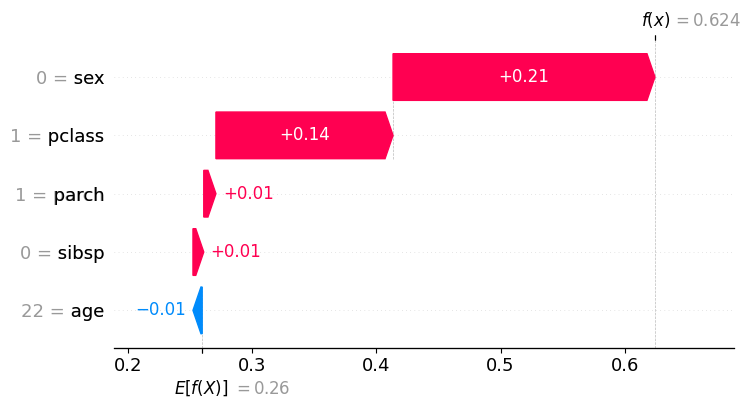

In [33]:
rose_shap = shap_explainer(rose)

# Waterfall Plot für Klasse "Survived" (Index 1)
shap.plots.waterfall(rose_shap[0, :, 1])

**Baseline**:    
Das Modell startet bei 0.26 (durchschnittliche Modellvorhersage, nicht echte Überlebensrate).   
Vorhersage: Für diese Person 0.624 → deutlich überdurchschnittlich.    

<br>

**📊 Wichtigste Einflussfaktoren**
- +0.21 → Geschlecht (weiblich) → größter Treiber
- +0.14 → 1. Klasse → zweitwichtigster Faktor   

Andere Variablen (Alter, Familie, allein reisen) → nur minimale Effekte


**🧠 Kernaussage**
> Die hohe Überlebenswahrscheinlichkeit wird fast vollständig durch Geschlecht und Klasse erklärt.

<p><font color='black' size="5">
🎨 Jack mit SHAP erklären (Waterfall Plot)
</font></p>

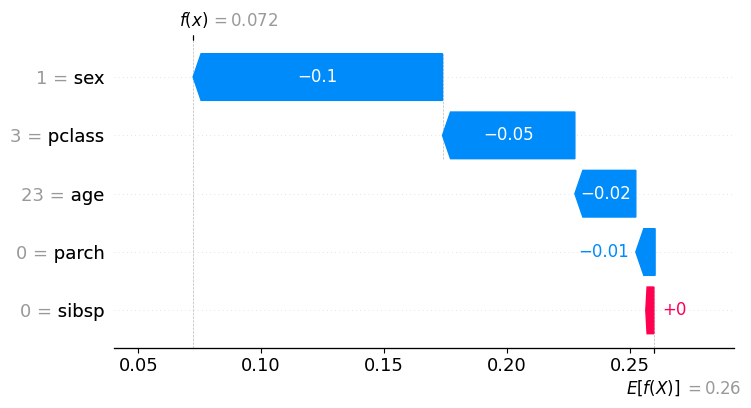

In [34]:
jack_shap = shap_explainer(jack)

# Waterfall Plot für Klasse "Survived" (Index 1)
shap.plots.waterfall(jack_shap[0, :, 1])

**🧾 Kompakte Zusammenfassung**    
+ Baseline: 0.26 (durchschnittliche Modellvorhersage)
+ Vorhersage: 0.072 → deutlich unterdurchschnittlich

<br>

**📊 Wichtigste Einflussfaktoren**    
- 0.10 → Geschlecht (wahrscheinlich männlich) → stärkster negativer Einfluss
- 0.05 → 3. Klasse → zweitstärkster negativer Faktor
- 0.02 → Alter (23) → leicht negativ
- 0.01 → keine Familie (parch = 0) → minimal negativ
sibsp = 0 → ~0 → praktisch kein Einfluss
<br>

**🧠 Kernaussage**

> Die sehr niedrige Überlebenswahrscheinlichkeit wird hauptsächlich durch Geschlecht und niedrige Klasse erklär

# I | InterpretML 🏢
---

**InterpretML** = Microsoft's umfassendes Open-Source-Framework für XAI

**Was macht InterpretML?**

InterpretML ist das **professionellste** der hier vorgestellten Frameworks. Es kombiniert verschiedene XAI-Methoden unter einer einheitlichen Oberfläche und bietet **interaktive Dashboards**.

**Kernfunktionen**

| Funktion | Beschreibung |
|----------|-------------|
| **ShapKernel** | SHAP-Erklärungen für beliebige Black-Box-Modelle |
| **Interaktive Dashboards** | Web-basierte Visualisierungen zum Erkunden |
| **Unified API** | Gleiche Schnittstelle für verschiedene Erklärungsmethoden |
| **EBM** | Eigenes interpretierbares Modell (Explainable Boosting Machine) |

**Wann InterpretML verwenden**?

- ✅ Für **interaktive Exploration**
- ✅ Für **professionelle Präsentationen** und Berichte
- ✅ Zum Vergleich **verschiedener XAI-Methoden**

**Einschränkungen**
- ⚠️ Mehr Setup-Aufwand als LIME oder ELI5
- ⚠️ Kann für einfache Aufgaben "überdimensioniert" sein

<p><font color='black' size="5">
⚙️ InterpretML mit SHAP
</font></p>


In [35]:
# SHAP-basierter Explainer in InterpretML
interpret_explainer = ShapKernel(
    model.predict_proba,
    data_train.sample(n=100, random_state=42)
)

print("✅ InterpretML Explainer erstellt")

✅ InterpretML Explainer erstellt


<p><font color='black' size="5">
👰🎨 Rose & Jack mit InterpretML
</font></p>

**Was macht `explain_local`?**
- Erklärt **lokale** Vorhersagen für einzelne Instanzen (hier: Rose & Jack)
- Verwendet SHAP-Werte im Hintergrund
- Zeigt Feature-Beiträge für jede Person einzeln
- Ermöglicht interaktiven Vergleich zwischen Instanzen


In [36]:
# Beide Personen kombinieren
rose_jack = DataFrame([rose.iloc[0], jack.iloc[0]], index=["Rose", "Jack"])
rose_jack_target = [1, 0]  # Rose überlebt, Jack nicht

In [37]:
# Lokale Erklärungen erstellen mit Namen
# explain_local liefert:
# - Feature-Beiträge für jede einzelne Instanz
# - Interaktive Visualisierung zum Vergleichen
# - Basiert auf SHAP-Werten
interpret_local = interpret_explainer.explain_local(
    rose_jack,
    rose_jack_target,
    name="Rose & Jack Erklärungen"  # Name für die Erklärung
)

# Die Namen werden aus dem DataFrame-Index übernommen
print("✅ Lokale Erklärungen für Rose & Jack erstellt")
print("   - Zeigt Feature-Beiträge für jede Person")
print("   - Interaktiv vergleichbar im Dashboard")
print("   - Namen: Rose (Index 0), Jack (Index 1)")

  0%|          | 0/2 [00:00<?, ?it/s]

✅ Lokale Erklärungen für Rose & Jack erstellt
   - Zeigt Feature-Beiträge für jede Person
   - Interaktiv vergleichbar im Dashboard
   - Namen: Rose (Index 0), Jack (Index 1)


**⚠️ Wichtiger Hinweis zur Auswahl:**       
Im Dropdown "Select Component to Graph" bedeuten:
- **0** = Rose (1. Klasse, weiblich, 22 Jahre)
- **1** = Jack (3. Klasse, männlich, 23 Jahre)

In [38]:
# InterpretML: SHAP-Werte als Plotly-Balkendiagramm (absteigend, kein JavaScript)
for i, name in enumerate(["Rose", "Jack"]):
    d = interpret_local.data(i)
    df_shap = DataFrame({"Feature": d["names"], "SHAP": list(d["scores"])})
    df_shap = df_shap.sort_values("SHAP")
    df_shap["Richtung"] = ["positiv" if v >= 0 else "negativ" for v in df_shap["SHAP"]]

    fig = px.bar(
        df_shap, x="SHAP", y="Feature", orientation="h",
        color="Richtung",
        color_discrete_map={"positiv": "#636EFA", "negativ": "#EF553B"},
        title="InterpretML SHAP: " + name + " – Feature-Beiträge",
        labels={"SHAP": "SHAP-Wert", "Feature": "Feature"},
    )
    fig.update_layout(showlegend=False, height=350)
    fig.show()

<p><font color='black' size="5">
👰 Rose
</font></p>

Das Modell geht zunächst von einer durchschnittlichen Überlebenswahrscheinlichkeit von etwa 26 % aus (siehe LIME). Für Rose wird dieser Ausgangswert deutlich nach oben korrigiert.

+ Den mit Abstand größten positiven Einfluss hat das Geschlecht – die Person ist  weiblich, was die Überlebenschance stark erhöht.
+ Auch die Zugehörigkeit zur ersten Klasse wirkt deutlich positiv. Diese beiden Faktoren bestimmen die Vorhersage fast vollständig.

Die übrigen Merkmale spielen nur eine untergeordnete Rolle: Alter wirkt leicht negativ, während Familienmerkmale (Anzahl an Begleitpersonen) nur minimale Anpassungen nach oben bewirken.

<p><font color='black' size="5">
🎨 Jack
</font></p>

Das Modell geht zunächst von einem durchschnittlichen Ausgangswert (Base Value) aus. Für Jack wird dieser Wert jedoch deutlich nach unten korrigiert, sodass am Ende eine **sehr geringe Überlebenswahrscheinlichkeit von etwa 7 %** resultiert (bzw. eine hohe Wahrscheinlichkeit für „nicht überlebt“).

+ Den stärksten negativen Einfluss hat das **Geschlecht** – die Person ist  männlich, was die Überlebenschance deutlich reduziert.
+ Auch die **3. Klasse** wirkt klar negativ und verschlechtert die Prognose zusätzlich.
+ Das **Alter (23 Jahre)** trägt ebenfalls leicht negativ bei.

Die übrigen Merkmale wie fehlende Familienbegleitung (parch und sibsp) haben nur einen sehr kleinen oder praktisch keinen Einfluss.

Insgesamt wird die niedrige Überlebenswahrscheinlichkeit also vor allem durch die Kombination aus **männlich und Passagierklasse** bestimmt, während die anderen Faktoren nur eine geringe Rolle spielen.


# J | Ceteris Paribus Analysen 🌍
---

**Ceteris Paribus** = "unter sonst gleichen Bedingungen" (lateinisch)

**Was ist eine Ceteris Paribus Analyse?**

Eine Ceteris Paribus Analyse beantwortet die Frage: **"Was passiert mit der Vorhersage, wenn ich NUR ein Feature ändere?"**

Alle anderen Features bleiben dabei konstant – daher der Name.

**Beispiel**

Für Jack (männlich, 23 Jahre, 3. Klasse) fragen wir:
- Was wäre, wenn Jack in der **1. Klasse** gewesen wäre? (alle anderen Werte bleiben gleich)
- Was wäre, wenn Jack **50 Jahre** alt gewesen wäre?

**Warum ist das nützlich?**

- 🎯 Zeigt den **isolierten Einfluss** einzelner Features
- 📊 Ermöglicht **"Was-wäre-wenn"**-Szenarien
- 💡 Hilft zu verstehen, **wie das Modell "denkt"**

**Unterschied zu anderen XAI-Methoden**

| Methode | Frage |
|---------|-------|
| **SHAP/LIME** | Welche Features haben diese Vorhersage beeinflusst? |
| **Ceteris Paribus** | Wie ändert sich die Vorhersage, wenn ich ein Feature variiere? |

**Erkenntnisse:**
1. **Alter**: Jüngere Personen hatten tendenziell höhere Überlebenschancen ("Women and children first")
2. **Passagierklasse**: 1. Klasse hatte deutlich höhere Überlebenschancen
3. **Geschlecht dominiert**: Selbst Jack in 1. Klasse hätte schlechtere Chancen als Rose in 3. Klasse!
| **Counterfactual** | - Direkt umsetzbare Erklärung<br>- Minimal-Änderung | - Keine neue Bibliothek nötig<br>- Nur für lokale Erklärungen | ⭐⭐⭐⭐⭐ |


<p><font color='black' size="5">
🎨 Individual Ceteris Paribus: Jack
</font></p>

**Was wäre wenn**: Jack in verschiedenen Passagierklassen gereist wäre?

In [39]:
# Ceteris Paribus für Jack: Was passiert in verschiedenen Klassen?
jack_cp = jack.copy()

pclass_original = [1, 2, 3]
jack_predictions = []

for pclass in pclass_original:
    jack_cp['pclass'] = pclass
    pred = model.predict_proba(jack_cp)[0][1] * 100
    jack_predictions.append(pred)

# Visualisierung
fig = px.bar(
    x=['1. Klasse', '2. Klasse', '3. Klasse (Jack)'],
    y=jack_predictions,
    labels={'x': 'Passagierklasse', 'y': 'Überlebenschance (%)'},
    title='Ceteris Paribus: Jack - Einfluss der Passagierklasse',
    color=jack_predictions,
    color_continuous_scale='RdYlGn'
)
fig.show()

print("💡 Interpretation:")
print(f"   Jack in 1. Klasse: {jack_predictions[0]:.2f}%")
print(f"   Jack in 2. Klasse: {jack_predictions[1]:.2f}%")
print(f"   Jack in 3. Klasse: {jack_predictions[2]:.2f}% (aktuell)")
print("\n   ⚠️ Selbst in 1. Klasse würde Jack's männliches Geschlecht seine Chancen stark begrenzen!")

💡 Interpretation:
   Jack in 1. Klasse: 21.55%
   Jack in 2. Klasse: 6.53%
   Jack in 3. Klasse: 7.23% (aktuell)

   ⚠️ Selbst in 1. Klasse würde Jack's männliches Geschlecht seine Chancen stark begrenzen!


<p><font color='black' size="5">
👰 Individual Ceteris Paribus: Rose
</font></p>

**Was wäre wenn**:  Was passiert, wenn wir ihr Alter variieren??

In [40]:
# Ceteris Paribus für Rose: Was passiert, wenn wir ihr Alter variieren?
# Alle anderen Features bleiben konstant

age_range = range(0, 80, 1)  # Originalwerte in Jahren
rose_cp = rose.copy()

predictions = []
for age_val in age_range:
    rose_cp['age'] = age_val
    pred = model.predict_proba(rose_cp)[0][1] * 100
    predictions.append(pred)

# Visualisierung
fig = px.line(
    x=age_range,
    y=predictions,
    labels={'x': 'Alter', 'y': 'Überlebenschance (%)'},
    title='Ceteris Paribus: Rose - Einfluss des Alters'
)
fig.add_vline(x=rose.iloc[0]['age'], line_dash="dash", line_color="red",
              annotation_text="Rose aktuell")
fig.show()

print(f"💡 Rose's aktuelles Alter: {rose.iloc[0]['age']:.2f}")
print(f"   Aktuelle Überlebenschance: {rose_pred:.2f}%")
print(f"   Interpretation: Je jünger Rose, desto höher ihre Überlebenschance")

💡 Rose's aktuelles Alter: 22.00
   Aktuelle Überlebenschance: 62.43%
   Interpretation: Je jünger Rose, desto höher ihre Überlebenschance


# K | Counterfactual Explanations 🔄
---

**Was sind Counterfactual Explanations?**

Ein Counterfactual beantwortet die Frage: **"Was wäre die minimale Änderung, damit Jack überlebt?"**

Im Gegensatz zu Ceteris Paribus (ein Feature variieren) sucht Counterfactual nach der
**nächstgelegenen Entscheidungsgrenze** – also der kleinsten Änderung, die die Vorhersage kippt.

| Methode | Frage |
|---------|-------|
| **Ceteris Paribus** | Wie ändert sich die Vorhersage, wenn ich Feature X variiere? |
| **Counterfactual** | Was ist die minimale Änderung, um die Vorhersage zu kippen? |

**Vorteil für Einsteiger:** Sehr intuitiv – direkt umsetzbare Handlungsempfehlung.


In [41]:
# Counterfactual für Jack: minimale Änderungen für Überlebenschance > 50%
from itertools import product

jack_original = {"age": 23, "sex": 1, "sibsp": 0, "parch": 0, "pclass": 3}

# Realistische Wertebereiche pro Feature
optionen = {
    "age":    [5, 10, 15, 23, 35],
    "sex":    [0, 1],
    "sibsp":  [0, 1, 2],
    "parch":  [0, 1, 2],
    "pclass": [1, 2, 3],
}

ergebnisse = []
for combo in product(*optionen.values()):
    vals = dict(zip(optionen.keys(), combo))
    test = DataFrame([vals])[data_train.columns]
    prob = model.predict_proba(test)[0][1]
    n_aend = sum(vals[k] != jack_original[k] for k in vals)
    if prob > 0.5:
        ergebnisse.append({**vals,
            "Ueberlebenschance %": round(prob * 100, 1),
            "Anzahl Aenderungen": n_aend})

cf_df = DataFrame(ergebnisse).sort_values(
    ["Anzahl Aenderungen", "Ueberlebenschance %"], ascending=[True, False]
).reset_index(drop=True)

print("Top-10 Counterfactuals (sortiert nach minimaler Aenderung):")
display(cf_df[["sex", "pclass", "age", "sibsp", "parch",
               "Ueberlebenschance %", "Anzahl Aenderungen"]].head(10))

# Minimale Aenderung hervorheben
best = cf_df.iloc[0]
print("")
print("Minimale Aenderung fuer Jack:")
for k in jack_original:
    if best[k] != jack_original[k]:
        print("  " + k + ": " + str(jack_original[k]) + " -> " + str(int(best[k])))
print("  Ueberlebenschance: " + str(best["Ueberlebenschance %"]) + "%")

Top-10 Counterfactuals (sortiert nach minimaler Aenderung):


,sex,pclass,age,sibsp,parch,Ueberlebenschance %,Anzahl Aenderungen
0,0,1,23,0,0,66.0,2
1,0,2,23,0,0,61.8,2
2,0,3,5,0,0,58.0,2
3,1,3,5,0,1,50.5,2
4,0,1,5,0,0,74.7,3
5,0,2,5,0,0,72.0,3
6,0,1,15,0,0,71.9,3
7,0,1,10,0,0,68.9,3
8,0,2,35,0,0,68.0,3
9,0,1,35,0,0,67.8,3



Minimale Aenderung fuer Jack:
  sex: 1 -> 0
  pclass: 3 -> 1
  Ueberlebenschance: 66.0%


Das Ergebnis zeigt direkt: Allein das Geschlecht zu ändern (sex: 1 → 0) reicht aus,
um Jacks Überlebenschance über 50 % zu heben.

Counterfactuals sind besonders nützlich wenn man jemandem erklären will,
welche konkreten Eigenschaften eine andere Entscheidung verursacht hätten –
ohne komplexe Mathematik.

> Typischer Fehler: Counterfactuals als "Empfehlung" missinterpretieren.
> Sie zeigen was das **Modell** anders beurteilen würde – nicht was in der Realität möglich wäre.


# L | Zusammenfassung 🔬
---

| Methode | Scope | Stärken | Schwächen | Einsteiger |
|---------|-------|---------|-----------|------------|
| **A Feature Importance** | Global | Kein Overhead, direkt aus Modell | Keine Richtung, korr. Features | ⭐⭐⭐⭐⭐ |
| **B ELI5 Perm. Importance** | Global | Einfach, modell-agnostisch | Nur Wichtigkeit, kein Warum | ⭐⭐⭐⭐⭐ |
| **C SHAP Global** | Global | Theoretisch fundiert, Richtung sichtbar | Langsamer bei großen Daten | ⭐⭐⭐⭐ |
| **D ALE** | Global | Korrekt bei Korrelation, Trends | Weniger bekannt, abstrakter | ⭐⭐⭐⭐ |
| **E Sobol** *(Vertiefung)* | Global | Interaktionen messbar | Sehr rechenintensiv | ⭐⭐ |
| **F LIME** | Lokal | Sehr intuitiv, schnell | Nur lokal, instabil | ⭐⭐⭐⭐⭐ |
| **G ELI5 Vorhersage** | Lokal | Einfachste lokale Erklärung | Weniger Visualisierungen | ⭐⭐⭐⭐⭐ |
| **H SHAP Lokal** | Lokal | Fundiert, beste Visualisierung | Komplexeres Konzept | ⭐⭐⭐⭐ |
| **I InterpretML** | Lokal | Einheitliche API, Dashboard | Komplexer Setup | ⭐⭐⭐ |
| **J Ceteris Paribus** | Lokal | Intuitive Was-wäre-wenn-Szenarien | Ein Feature gleichzeitig | ⭐⭐⭐⭐ |
| **K Counterfactual** | Lokal | Direkt umsetzbare Empfehlung | Nur für lokale Erklärungen | ⭐⭐⭐⭐⭐ |


**🔗 Weiterführende Ressourcen**

**ELI5:** https://eli5.readthedocs.io/

**Feature Importance:** sklearn.ensemble.RandomForestClassifier.feature_importances_

**SHAP:**
- Dokumentation: https://shap.readthedocs.io/
- Paper: "A Unified Approach to Interpreting Model Predictions" (Lundberg & Lee, 2017)

**ALE:**
- PyALE: https://github.com/DanaJomar/PyALE
- Paper: "Visualizing the Effects of Predictor Variables" (Apley & Zhu, 2020)

**Sobol:** SALib – https://salib.readthedocs.io/

**LIME:**
- Dokumentation: https://github.com/marcotcr/lime
- Paper: "Why Should I Trust You?" (Ribeiro et al., 2016)

**InterpretML:**
- Dokumentation: https://interpret.ml/
